<a href="https://colab.research.google.com/github/RajeshVulasala/Data-Analysis-on-Solid-Waste-Management-/blob/main/Data_Analysis_on_Solid_Waste_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA ANALYSIS ON SOLID WASTE MANAGEMENT

In [ ]:
# IMPORTING THE PANDAS & NUMPY
import pandas as pd
import numpy as np

## Case Study : Pune Dataset

In [ ]:
# load pune data set
df = pd.read_csv(r"C:\Users\vulas\Downloads\PUNE-SW.csv")

In [ ]:
# inspecting the dataset

In [ ]:
df.head()

,City Name,Zone Name,Ward name,Number of HH,Waste quantity (Tonnes Per Day),No. of Households with waste segregation
0,Pune,Nagar Road-Wadgaon Sheri,Viman Nagar,109555,27.21,109555
1,Pune,NaN,Kharadi-Chandan Nagar,101503,29.28,101503
2,Pune,NaN,Wadgaon-Sheri-Kalyani nagar,107795,23.67,107795
3,Pune,Yerwada kalas Dhanori,Kalas-Dhanori,151809,36.96,151809
4,Pune,NaN,Phule Nagar-Nagpur Chwal,94845,37.54,94845


In [ ]:
df.shape

(42, 6)

In [ ]:
cols = df.columns
print(cols)

Index(['City Name', 'Zone Name', 'Ward name', 'Number of HH',
       'Waste quantity (Tonnes Per Day)',
       'No. of Households with waste segregation'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 6 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   City Name                                 42 non-null     object 
 1   Zone Name                                 16 non-null     object 
 2   Ward name                                 42 non-null     object 
 3   Number of HH                              42 non-null     int64  
 4   Waste quantity (Tonnes Per Day)           42 non-null     float64
 5   No. of Households with waste segregation  42 non-null     int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 2.1+ KB


In [ ]:
# checking missing values
df.isnull().sum()

City Name                                    0
Zone Name                                   26
Ward name                                    0
Number of HH                                 0
Waste quantity (Tonnes Per Day)              0
No. of Households with waste segregation     0
dtype: int64

In [ ]:
# checking the duplicate rows
duplicates = df.duplicated().sum()
print(duplicates)

0


In [ ]:
df.describe()

,Number of HH,Waste quantity (Tonnes Per Day),No. of Households with waste segregation
count,42.000000,42.000000,42.000000
mean,102243.500000,37.915000,102243.500000
std,47162.952334,11.704138,47162.952334
min,15753.000000,14.640000,15753.000000
25%,83112.000000,28.682500,83112.000000
50%,101362.500000,38.340000,101362.500000
75%,111888.750000,44.737500,111888.750000
max,260669.000000,66.530000,260669.000000


In [ ]:
# Data Cleaning

we already know there is a problem with missing Zone Name values. Before changing anything, we'll inspect the missing records.

In [ ]:
# finding missing zone values
df[df["Zone Name"].isnull()]

,City Name,Zone Name,Ward name,Number of HH,Waste quantity (Tonnes Per Day),No. of Households with waste segregation
1,Pune,NaN,Kharadi-Chandan Nagar,101503,29.28,101503
2,Pune,NaN,Wadgaon-Sheri-Kalyani nagar,107795,23.67,107795
4,Pune,NaN,Phule Nagar-Nagpur Chwal,94845,37.54,94845
5,Pune,NaN,Yerawada,35582,22.35,35582
7,Pune,NaN,Koregain Park-Ghorpadi,102118,36.49,102118
9,Pune,NaN,Baner-Balewadi-pashan,126086,41.86,126086
11,Pune,NaN,Deccan Gymkhana-Model Colony,101222,53.87,101222
13,Pune,NaN,Rambaugh Colony-Shivtirth Nagar,102656,14.64,102656
14,Pune,NaN,Mayur Colony-Dahanukar Colony,87673,39.69,87673
16,Pune,NaN,Dhankawadi-Ambegaon Pathar,59265,44.00,59265


### Checking wether the missing values can be recovered

We want to see whether the ward information gives us enough context to determine the correct zone.

In [ ]:
df.columns

Index(['City Name', 'Zone Name', 'Ward name', 'Number of HH',
       'Waste quantity (Tonnes Per Day)',
       'No. of Households with waste segregation'],
      dtype='object')

In [ ]:
# the null values of ZONE NAME

df[df["Zone Name"].isnull()][["Ward name", "Number of HH", "Waste quantity (Tonnes Per Day)"]]

,Ward name,Number of HH,Waste quantity (Tonnes Per Day)
1,Kharadi-Chandan Nagar,101503,29.28
2,Wadgaon-Sheri-Kalyani nagar,107795,23.67
4,Phule Nagar-Nagpur Chwal,94845,37.54
5,Yerawada,35582,22.35
7,Koregain Park-Ghorpadi,102118,36.49
9,Baner-Balewadi-pashan,126086,41.86
11,Deccan Gymkhana-Model Colony,101222,53.87
13,Rambaugh Colony-Shivtirth Nagar,102656,14.64
14,Mayur Colony-Dahanukar Colony,87673,39.69
16,Dhankawadi-Ambegaon Pathar,59265,44.00


In [ ]:
# checking if the Number of HH & No. of Households with waste segregation are the same data

(df["Number of HH"] == df["No. of Households with waste segregation"]).value_counts()

True    42
Name: count, dtype: int64

In [ ]:
dtypes = df.dtypes
des = df.describe()

print(dtypes)
print(des)

City Name                                    object
Zone Name                                    object
Ward name                                    object
Number of HH                                  int64
Waste quantity (Tonnes Per Day)             float64
No. of Households with waste segregation      int64
dtype: object
        Number of HH  Waste quantity (Tonnes Per Day)  \
count      42.000000                        42.000000   
mean   102243.500000                        37.915000   
std     47162.952334                        11.704138   
min     15753.000000                        14.640000   
25%     83112.000000                        28.682500   
50%    101362.500000                        38.340000   
75%    111888.750000                        44.737500   
max    260669.000000                        66.530000   

       No. of Households with waste segregation  
count                                 42.000000  
mean                              102243.500000  
std       

### Creating our clean dataset

In [ ]:
clean = df.copy()

In [ ]:
# now removing the No. of Households with waste segregation column because it has same data as Number of HH

clean = clean.drop(columns=["No. of Households with waste segregation"])

In [ ]:
clean.head()

,City Name,Zone Name,Ward name,Number of HH,Waste quantity (Tonnes Per Day)
0,Pune,Nagar Road-Wadgaon Sheri,Viman Nagar,109555,27.21
1,Pune,NaN,Kharadi-Chandan Nagar,101503,29.28
2,Pune,NaN,Wadgaon-Sheri-Kalyani nagar,107795,23.67
3,Pune,Yerwada kalas Dhanori,Kalas-Dhanori,151809,36.96
4,Pune,NaN,Phule Nagar-Nagpur Chwal,94845,37.54


In [ ]:
clean.shape

(42, 5)

In [ ]:
# checking the missing values

clean.isnull().sum()

City Name                           0
Zone Name                          26
Ward name                           0
Number of HH                        0
Waste quantity (Tonnes Per Day)     0
dtype: int64

***Waste Generated per Household***

In [ ]:
waste_quant = clean["Waste quantity (Tonnes Per Day)"]
n_hh = clean["Number of HH"]
clean["Waste per HH"] = waste_quant / n_hh

In [ ]:
clean.head()

,City Name,Zone Name,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH
0,Pune,Nagar Road-Wadgaon Sheri,Viman Nagar,109555,27.21,0.000248
1,Pune,NaN,Kharadi-Chandan Nagar,101503,29.28,0.000288
2,Pune,NaN,Wadgaon-Sheri-Kalyani nagar,107795,23.67,0.000220
3,Pune,Yerwada kalas Dhanori,Kalas-Dhanori,151809,36.96,0.000243
4,Pune,NaN,Phule Nagar-Nagpur Chwal,94845,37.54,0.000396


**there's a small issue, The waste is measured in tonnes, so the value will be very small.
For easier interpretation, let's calculate kg per household per day**

In [ ]:
# waste kg per household a day
clean["Waste per HH"] = clean["Waste per HH"]*1000

In [ ]:
clean.head()

,City Name,Zone Name,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH
0,Pune,Nagar Road-Wadgaon Sheri,Viman Nagar,109555,27.21,0.248368
1,Pune,NaN,Kharadi-Chandan Nagar,101503,29.28,0.288464
2,Pune,NaN,Wadgaon-Sheri-Kalyani nagar,107795,23.67,0.219583
3,Pune,Yerwada kalas Dhanori,Kalas-Dhanori,151809,36.96,0.243464
4,Pune,NaN,Phule Nagar-Nagpur Chwal,94845,37.54,0.395804


In [ ]:
clean[["Ward name",	"Number of HH",	"Waste quantity (Tonnes Per Day)",	"Waste per HH"]].head(10)

,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH
0,Viman Nagar,109555,27.21,0.248368
1,Kharadi-Chandan Nagar,101503,29.28,0.288464
2,Wadgaon-Sheri-Kalyani nagar,107795,23.67,0.219583
3,Kalas-Dhanori,151809,36.96,0.243464
4,Phule Nagar-Nagpur Chwal,94845,37.54,0.395804
5,Yerawada,35582,22.35,0.628127
6,Tadiwala Road-Sasoon Hospital,90488,39.18,0.432986
7,Koregain Park-Ghorpadi,102118,36.49,0.357332
8,Aundh-Bopodi,229155,28.54,0.124545
9,Baner-Balewadi-pashan,126086,41.86,0.331996


### finding the highest waste generating wards

In [ ]:
# high waste to low waste generating ward

high_waste = clean.sort_values(by= "Waste quantity (Tonnes Per Day)", ascending = False)


high_waste[["Ward name",	"Number of HH",	"Waste quantity (Tonnes Per Day)",	"Waste per HH"]].head(10)

,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH
41,"Kondhwa-Yelwalewadi,Dhankawadi-Sahakanagar,Had...",173633,66.53,0.383164
39,Bibwewadi-Bibwewadi Gaothan,124583,60.03,0.481847
38,Salibary Park_ Mukund Nagar,104156,56.01,0.537751
31,Kondhwa Budruk-Yewalewadi,110751,55.21,0.498506
11,Deccan Gymkhana-Model Colony,101222,53.87,0.532197
15,Sahakarnagar-Padmavati,71929,49.92,0.694018
10,Pune University-Wakdewadi,63866,49.79,0.779601
26,Mohammad Wadi-Kausar Bhugh,110633,48.43,0.437754
34,Navi Peth-Parvati,86159,46.32,0.537611
29,Kondhwa Khurd-Mittha Nagar,27378,45.67,1.668128


In [ ]:
# lowest to highest generating ward
low_waste = clean.sort_values(
    by="Waste quantity (Tonnes Per Day)",
    ascending=True
)

low_waste[
    ["Ward name", "Number of HH", "Waste quantity (Tonnes Per Day)", "Waste per HH"]
].head(10)

,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH
13,Rambaugh Colony-Shivtirth Nagar,102656,14.64,0.142612
37,Lohiya Nagar-Kashewadi,107936,18.46,0.171027
5,Yerawada,35582,22.35,0.628127
27,Ramtekdi-Sasane Nagar,83988,22.74,0.270753
18,Janta Vasahat-Duttawadi,15753,23.57,1.496223
2,Wadgaon-Sheri-Kalyani nagar,107795,23.67,0.219583
25,Hadapsar Gaothan-Satav Wadi,187584,25.44,0.135619
36,khadakmal Ali-Mahatma Phule Peth,54172,26.71,0.493059
24,Mundhwa-Magarpatta City,112268,26.99,0.240407
0,Viman Nagar,109555,27.21,0.248368


In [ ]:
# highest waste per house hold

high_waste_hh = clean.sort_values(by = "Waste per HH", ascending = False)

high_waste_hh[
    ["Ward name", "Number of HH", "Waste quantity (Tonnes Per Day)", "Waste per HH"]
].head(10)

,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH
29,Kondhwa Khurd-Mittha Nagar,27378,45.67,1.668128
18,Janta Vasahat-Duttawadi,15753,23.57,1.496223
23,Warje-Malwadi,35058,39.14,1.116436
10,Pune University-Wakdewadi,63866,49.79,0.779601
16,Dhankawadi-Ambegaon Pathar,59265,44.00,0.742428
17,Dutta Nagar-Katraj Gaothan,62319,44.73,0.717759
15,Sahakarnagar-Padmavati,71929,49.92,0.694018
5,Yerawada,35582,22.35,0.628127
28,Wanawadi,69868,43.73,0.625895
38,Salibary Park_ Mukund Nagar,104156,56.01,0.537751


### Visualizing the top 10 wards by Total Waste

In [ ]:
top_wards_waste = high_waste.head(10)
print(top_wards_waste)

   City Name                 Zone Name  \
41      Pune                   Ward 42   
39      Pune                       NaN   
38      Pune                 Bibwewadi   
31      Pune                       NaN   
11      Pune                       NaN   
15      Pune    Dhanawadi Sahakarnagar   
10      Pune  Shivaji Nagar-Ghole Road   
26      Pune                       NaN   
34      Pune                       NaN   
29      Pune                       NaN   

                                            Ward name  Number of HH  \
41  Kondhwa-Yelwalewadi,Dhankawadi-Sahakanagar,Had...        173633   
39                        Bibwewadi-Bibwewadi Gaothan        124583   
38                        Salibary Park_ Mukund Nagar        104156   
31                          Kondhwa Budruk-Yewalewadi        110751   
11                       Deccan Gymkhana-Model Colony        101222   
15                             Sahakarnagar-Padmavati         71929   
10                          Pune Univers

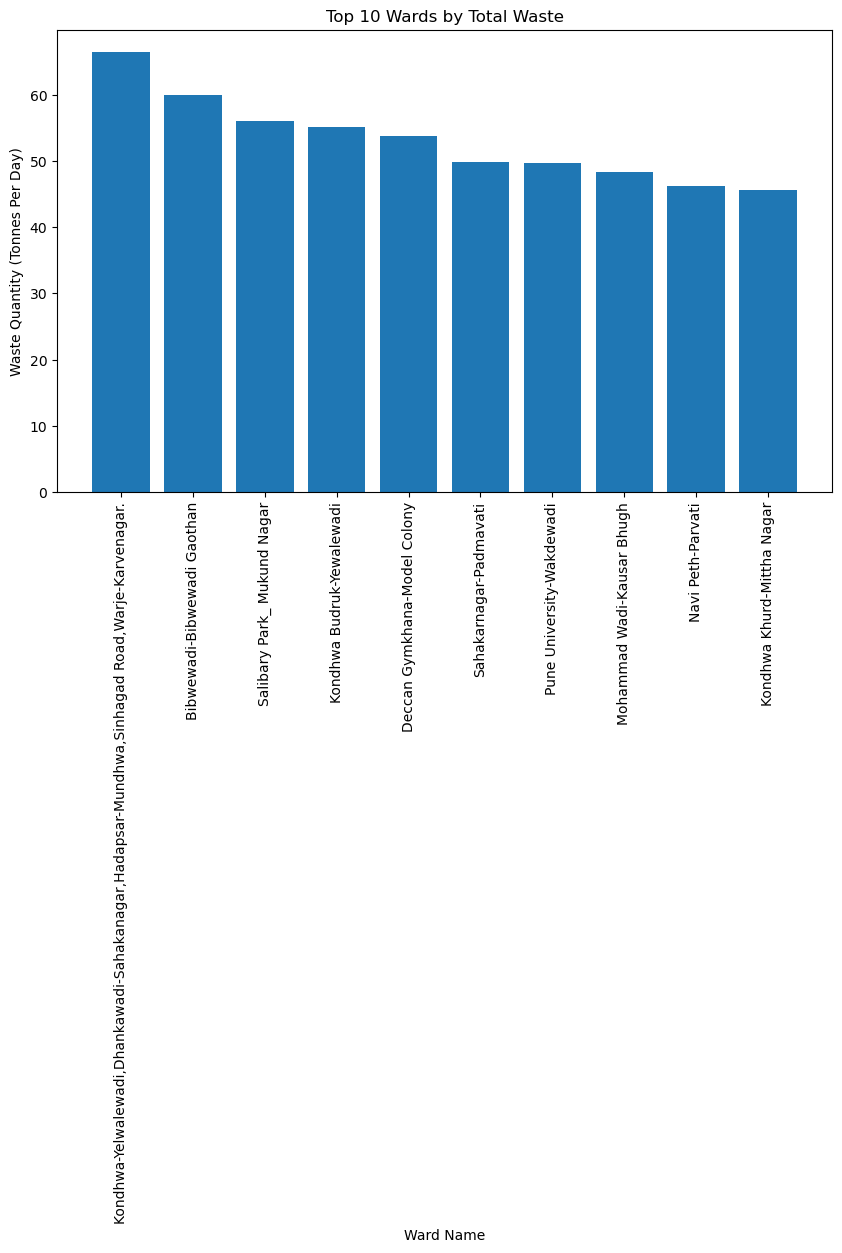

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(top_wards_waste["Ward name"],
        top_wards_waste["Waste quantity (Tonnes Per Day)"]
       )

plt.title("Top 10 Wards by Total Waste")
plt.xlabel("Ward Name")
plt.ylabel("Waste Quantity (Tonnes Per Day)")

plt.xticks(rotation = 90) # To rotate the labes on x axis to 90 degrees
# plt.yticks(rotation = 90)

plt.show()


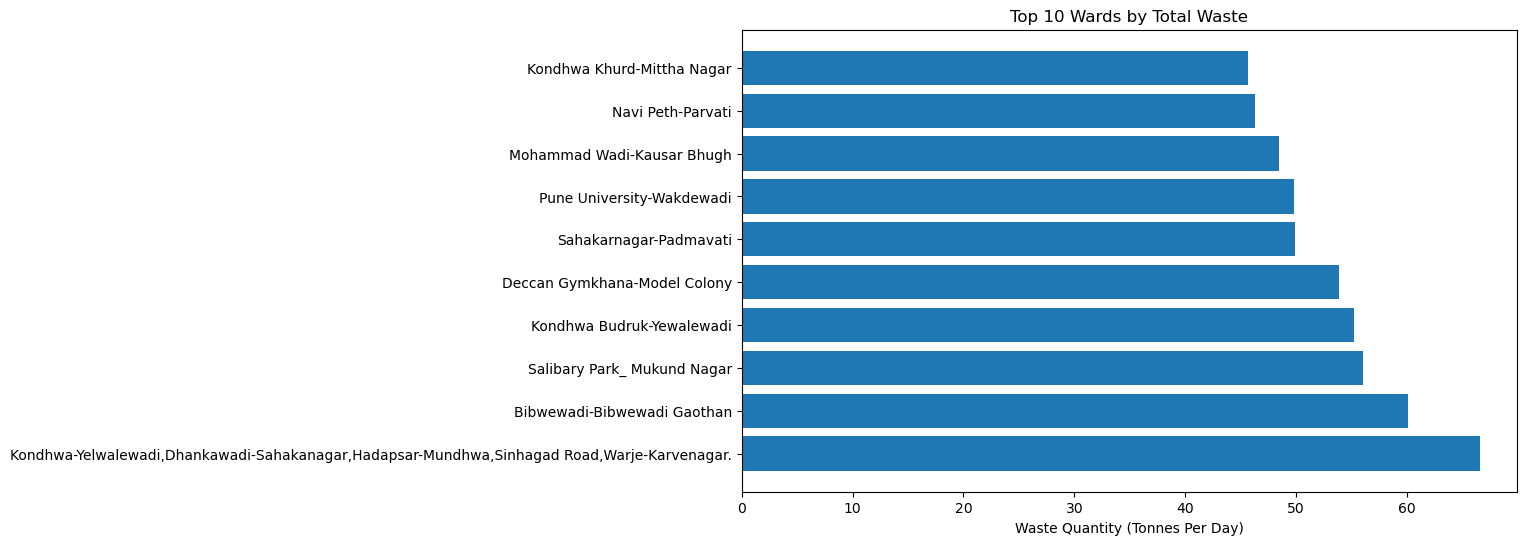

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_wards_waste["Ward name"],
    top_wards_waste["Waste quantity (Tonnes Per Day)"]
)

plt.xlabel("Waste Quantity (Tonnes Per Day)")
plt.title("Top 10 Wards by Total Waste")

# plt.gca().invert_yaxis() # this makes the y-axis upside-down

plt.show()

### Top 10 house holdes by total waste per day

In [ ]:
top_10_waste_per_hh = high_waste_hh.head(10)

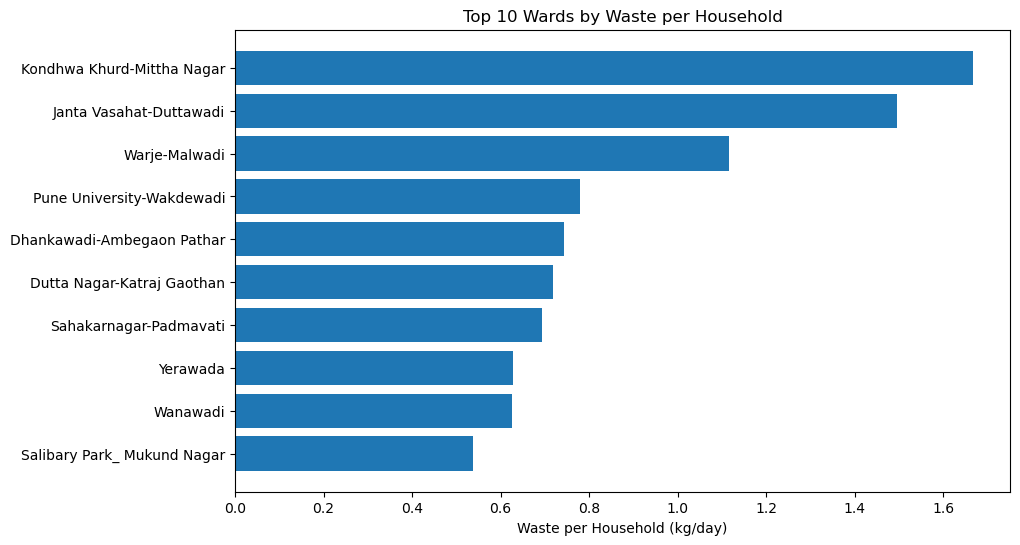

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_waste_per_hh["Ward name"],
    top_10_waste_per_hh["Waste per HH"]
)

plt.xlabel("Waste per Household (kg/day)")
# plt.ylabel("Ward")
plt.title("Top 10 Wards by Waste per Household")

plt.gca().invert_yaxis()

plt.show()

### check whether the number of households is related to total waste.

***Do wards with more households generally produce more total waste?***

In [ ]:
# relation b/w no. of hh and total waste

# correlation
correlation = clean["Number of HH"].corr(clean["Waste quantity (Tonnes Per Day)"])

print(correlation.round(3))


0.043


**The dataset shows a very weak linear relationship between household count and reported waste quantity**

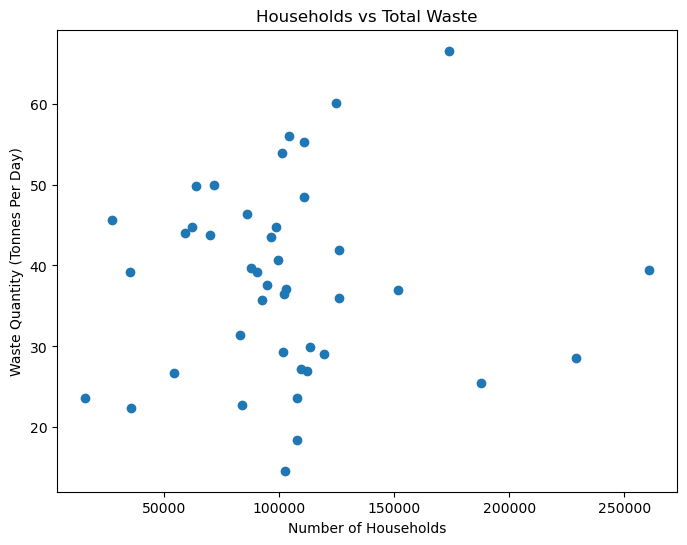

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    clean["Number of HH"],
    clean["Waste quantity (Tonnes Per Day)"]
)

plt.xlabel("Number of Households")
plt.ylabel("Waste Quantity (Tonnes Per Day)")
plt.title("Households vs Total Waste")

plt.show()

In [ ]:
OUTLIER ANALYSIS

In [ ]:
We want a baseline.

Then we can compare each ward against the average:

Above average → higher waste per household
Below average → lower waste per household

In [ ]:
print(clean)

   City Name                 Zone Name  \
0       Pune  Nagar Road-Wadgaon Sheri   
1       Pune                       NaN   
2       Pune                       NaN   
3       Pune     Yerwada kalas Dhanori   
4       Pune                       NaN   
5       Pune                       NaN   
6       Pune          Dhole Patil Road   
7       Pune                       NaN   
8       Pune               Aundh Baner   
9       Pune                       NaN   
10      Pune  Shivaji Nagar-Ghole Road   
11      Pune                       NaN   
12      Pune           Kothrud Bavdhan   
13      Pune                       NaN   
14      Pune                       NaN   
15      Pune    Dhanawadi Sahakarnagar   
16      Pune                       NaN   
17      Pune                       NaN   
18      Pune             Sinhagad Road   
19      Pune                       NaN   
20      Pune                       NaN   
21      Pune         Warje karve Nagar   
22      Pune                      

In [ ]:
avg_waste_hh = clean["Waste per HH"].mean()
print(avg_waste_hh.round(4))

0.4717


In [ ]:
# comparing the each house hold waste with mean waste per hh

clean["Difference from avg"] = (
    clean["Waste per HH"] - avg_waste_hh
)
clean

,City Name,Zone Name,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH,Difference from avg
0,Pune,Nagar Road-Wadgaon Sheri,Viman Nagar,109555,27.21,0.248368,-0.223286
1,Pune,NaN,Kharadi-Chandan Nagar,101503,29.28,0.288464,-0.183190
2,Pune,NaN,Wadgaon-Sheri-Kalyani nagar,107795,23.67,0.219583,-0.252071
3,Pune,Yerwada kalas Dhanori,Kalas-Dhanori,151809,36.96,0.243464,-0.228191
4,Pune,NaN,Phule Nagar-Nagpur Chwal,94845,37.54,0.395804,-0.075851
5,Pune,NaN,Yerawada,35582,22.35,0.628127,0.156472
6,Pune,Dhole Patil Road,Tadiwala Road-Sasoon Hospital,90488,39.18,0.432986,-0.038669
7,Pune,NaN,Koregain Park-Ghorpadi,102118,36.49,0.357332,-0.114323
8,Pune,Aundh Baner,Aundh-Bopodi,229155,28.54,0.124545,-0.347110
9,Pune,NaN,Baner-Balewadi-pashan,126086,41.86,0.331996,-0.139659


In [ ]:
# let's get in sorted order

clean[
    ["Ward name", "Waste per HH", "Difference from avg"]
    ].sort_values(
        by = "Difference from avg",
        ascending = False
    ).head(10)

# top 10 difference between mean and waste per hh

,Ward name,Waste per HH,Difference from avg
29,Kondhwa Khurd-Mittha Nagar,1.668128,1.196473
18,Janta Vasahat-Duttawadi,1.496223,1.024568
23,Warje-Malwadi,1.116436,0.644781
10,Pune University-Wakdewadi,0.779601,0.307946
16,Dhankawadi-Ambegaon Pathar,0.742428,0.270773
17,Dutta Nagar-Katraj Gaothan,0.717759,0.246104
15,Sahakarnagar-Padmavati,0.694018,0.222363
5,Yerawada,0.628127,0.156472
28,Wanawadi,0.625895,0.154240
38,Salibary Park_ Mukund Nagar,0.537751,0.066096


In [ ]:
# calculating the iqr

q1 = clean["Waste per HH"].quantile(0.25)
q3 = clean["Waste per HH"].quantile(0.75)

iqr = q3 - q1

# find the upper limit & Lower limit

upper_lmt = q3+1.5*iqr
lower_lmt = q1 - 1.5*iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Outlier Limit:", lower_lmt)
print("Upper Outlier Limit:", upper_lmt)

Q1: 0.26628915800075625
Q3: 0.536257161892358
IQR: 0.2699680038916017
Lower Outlier Limit: -0.13866284783664629
Upper Outlier Limit: 0.9412091677297605


In [ ]:
Finding the Outliers

In [ ]:
outliers = clean[
    clean["Waste per HH"] > upper_lmt
    ]

# outliers
outliers[
    ["Ward name","Number of HH","Waste quantity (Tonnes Per Day)","Waste per HH"]
]

,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH
18,Janta Vasahat-Duttawadi,15753,23.57,1.496223
23,Warje-Malwadi,35058,39.14,1.116436
29,Kondhwa Khurd-Mittha Nagar,27378,45.67,1.668128


In [ ]:
# outliers

**Outlier analysis identified three wards—Kondhwa Khurd-Mittha Nagar, Janta Vasahat-Duttawadi, and Warje-Malwadi—with waste generation above the calculated upper IQR limit of 0.941 kg per household per day. These wards may require further investigation to understand the reasons for their unusually high reported waste generation.**

In [ ]:
# ploting graph for outliers


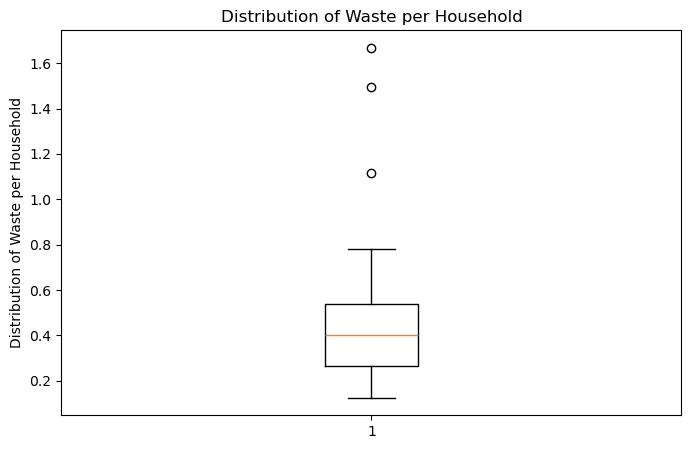

In [ ]:
plt.figure(figsize = (8,5))

plt.boxplot(clean["Waste per HH"])
plt.ylabel("Distribution of Waste per Household")
plt.title("Distribution of Waste per Household")
plt.show()

In [ ]:
Analyzing the outliers

In [ ]:
out = outliers[
    ["Ward name",
     "Number of HH",
     "Waste quantity (Tonnes Per Day)",
     "Waste per HH"]
]

In [ ]:
# comparing the 3 outlier wards with the overall average.

outlier_comp = out.copy()

outlier_comp["Difference from avg"] = (
    outlier_comp["Waste per HH"] - avg_waste_hh
)

outlier_comp

,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH,Difference from avg
18,Janta Vasahat-Duttawadi,15753,23.57,1.496223,1.024568
23,Warje-Malwadi,35058,39.14,1.116436,0.644781
29,Kondhwa Khurd-Mittha Nagar,27378,45.67,1.668128,1.196473


In [ ]:
print(out)
print("Average:", avg_waste_hh)

                     Ward name  Number of HH  Waste quantity (Tonnes Per Day)  \
18     Janta Vasahat-Duttawadi         15753                            23.57   
23               Warje-Malwadi         35058                            39.14   
29  Kondhwa Khurd-Mittha Nagar         27378                            45.67   

    Waste per HH  
18      1.496223  
23      1.116436  
29      1.668128  
Average: 0.47165477593986854


**Three wards show unusually high reported waste generation per household and are substantially above the overall dataset average. These wards should be investigated further to understand the factors contributing to the higher reported values.**

In [ ]:
# checking the outliers are among the top wards waste generation
outlier_comp [
    ["Ward name",
     "Number of HH",
     "Waste quantity (Tonnes Per Day)",
     "Waste per HH"]
    ].sort_values(
        by= "Waste quantity (Tonnes Per Day)", ascending = False)

,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH
29,Kondhwa Khurd-Mittha Nagar,27378,45.67,1.668128
23,Warje-Malwadi,35058,39.14,1.116436
18,Janta Vasahat-Duttawadi,15753,23.57,1.496223


In [ ]:
# Household Count vs Waste per Household

corr_waste_hh = clean["Number of HH"].corr(clean["Waste per HH"])
print(corr_waste_hh)

-0.6933283858408916


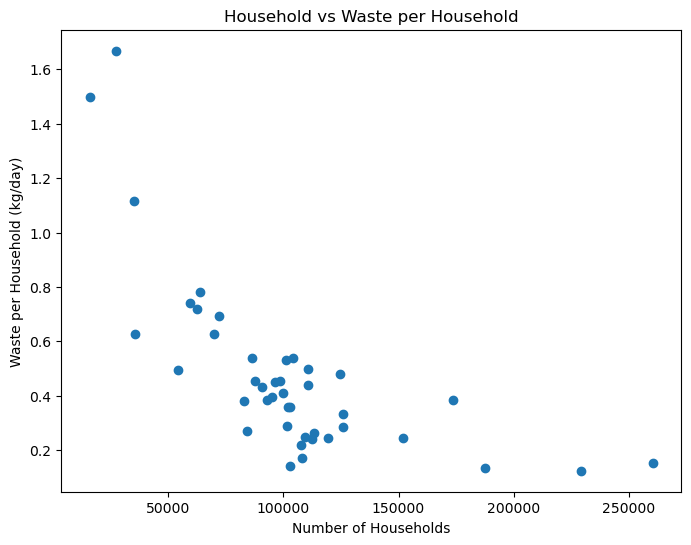

In [ ]:
# Do wards with more households tend to have higher or lower waste generation per household?

plt.figure(figsize=(8,6))
plt.scatter(clean["Number of HH"], clean["Waste per HH"])
plt.xlabel("Number of Households")
plt.ylabel("Waste per Household (kg/day)")
plt.title("Household vs Waste per Household")
plt.show()

In [ ]:
corr_waste_per_hh = clean["Number of HH"].corr(clean["Waste per HH"])
print(corr_waste_per_hh)

-0.6933283858408916


**The dataset shows a moderately strong negative correlation (r = -0.693) between household count and waste generated per household, indicating that wards with larger household counts tend to report lower waste per household.**

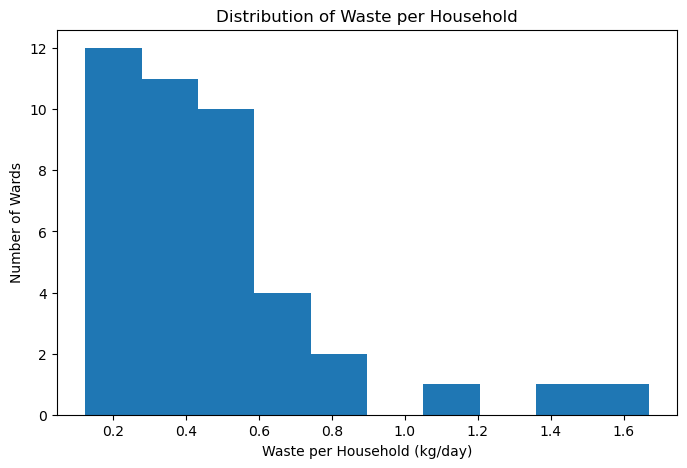

In [ ]:
# understanding the distribution of our Waste per HH values.

# How are the waste-per-household values distributed across all wards?

plt.figure(figsize = (8,5))
plt.hist(clean["Waste per HH"], bins = 10)
plt.xlabel("Waste per Household (kg/day)")
plt.ylabel("Number of Wards")
plt.title("Distribution of Waste per Household")

plt.show()

In [ ]:
# Comparing total waste with waste per household for all wards.

In [ ]:
# finding the median
median_total_waste = clean["Waste quantity (Tonnes Per Day)"].median()
median_waste_hh = clean["Waste per HH"].median()

print("Median Total Waste:", median_total_waste)
print("Median Waste per HH:", median_waste_hh)

Median Total Waste: 38.34
Median Waste per HH: 0.40210523103408113


In [ ]:
# Create the four categories
clean["Waste Burden"] = clean.apply(
    lambda row:
        "High Total Waste + High Waste/HH"
        if row["Waste quantity (Tonnes Per Day)"] > median_total_waste
        and row["Waste per HH"] > median_waste_hh

        else "High Total Waste + Low Waste/HH"
        if row["Waste quantity (Tonnes Per Day)"] > median_total_waste
        and row["Waste per HH"] <= median_waste_hh

        else "Low Total Waste + High Waste/HH"
        if row["Waste quantity (Tonnes Per Day)"] <= median_total_waste
        and row["Waste per HH"] > median_waste_hh

        else "Low Total Waste + Low Waste/HH",
    axis=1
)

In [ ]:
clean["Waste Burden"].value_counts()

Waste Burden
Low Total Waste + Low Waste/HH      18
High Total Waste + High Waste/HH    18
Low Total Waste + High Waste/HH      3
High Total Waste + Low Waste/HH      3
Name: count, dtype: int64

In [ ]:
# what are the top 3 wards and least 3 wards
clean[
    clean["Waste Burden"].isin([
        "Low Total Waste + High Waste/HH",
        "High Total Waste + Low Waste/HH"
    ])
][[
    "Ward name",
    "Number of HH",
    "Waste quantity (Tonnes Per Day)",
    "Waste per HH",
    "Waste Burden"
]]

,Ward name,Number of HH,Waste quantity (Tonnes Per Day),Waste per HH,Waste Burden
5,Yerawada,35582,22.35,0.628127,Low Total Waste + High Waste/HH
9,Baner-Balewadi-pashan,126086,41.86,0.331996,High Total Waste + Low Waste/HH
18,Janta Vasahat-Duttawadi,15753,23.57,1.496223,Low Total Waste + High Waste/HH
32,Shaniwar Peth-Sadashiv Peth,260669,39.50,0.151533,High Total Waste + Low Waste/HH
36,khadakmal Ali-Mahatma Phule Peth,54172,26.71,0.493059,Low Total Waste + High Waste/HH
41,"Kondhwa-Yelwalewadi,Dhankawadi-Sahakanagar,Had...",173633,66.53,0.383164,High Total Waste + Low Waste/HH
